In [1]:
# https://hoohm.github.io/CITE-seq-Count/

In [2]:
setwd("/home/tanasa/CITEseq")

In [3]:
# We use the CITE-seq dataset from (Stuart*, Butler* et al, Cell 2019), 
# which consists of 30,672 scRNA-seq profiles measured alongside 
# a panel of 25 antibodies from bone marrow. 
# The object contains two assays, RNA and antibody-derived tags (ADT).

In [4]:
# In (Hao*, Hao* et al, Cell 2021 Login to Jenni), we introduce ‘weighted-nearest neighbor’ (WNN) analysis, 
# an unsupervised framework to learn the relative utility of each data type in each cell, 
# enabling an integrative analysis of multiple modalities.

In [5]:
# wget https://ftp.ncbi.nlm.nih.gov/geo/series/GSE100nnn/GSE100866/suppl/GSE100866_CBMC_8K_13AB_10X-RNA_umi.csv.gz
# wget https://ftp.ncbi.nlm.nih.gov/geo/series/GSE100nnn/GSE100866/suppl/GSE100866_CBMC_8K_13AB_10X-ADT_umi.csv.gz

In [6]:
library(Seurat)
library(SeuratData)
library(cowplot)
library(dplyr)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


── Installed datasets ──────────────────────────────────────────────────────────── SeuratData v0.2.2.9001 ──

✔ bmcite 0.3.0                                        


──────────────────────────────────────────────────── Key ───────────────────────────────────────────────────

✔ Dataset loaded successfully
❯ Dataset built with a newer version of Seurat than installed
❓ Unknown version of Seurat installed



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [7]:
# https://satijalab.org/seurat/articles/weighted_nearest_neighbor_analysis

In [8]:
cat("WNN analysis of CITE-seq, RNA + ADT")

WNN analysis of CITE-seq, RNA + ADT

In [9]:
InstallData("bmcite")
bm <- LoadData(ds = "bmcite")

Warning message:
“The following packages are already installed and will not be reinstalled: bmcite”
Validating object structure

Updating object slots

Ensuring keys are in the proper structure

Updating matrix keys for DimReduc ‘spca’

Warning message:
“Assay RNA changing from Assay to Assay”
Warning message:
“Assay ADT changing from Assay to Assay”
Warning message:
“Graph wknn changing from Graph to Graph”
Warning message:
“Graph wsnn changing from Graph to Graph”
Warning message:
“DimReduc spca changing from DimReduc to DimReduc”
Ensuring keys are in the proper structure

Ensuring feature names don't have underscores or pipes

Updating slots in RNA

Updating slots in ADT

Updating slots in wknn

Cannot find wknn in the object, setting default assay of wknn to RNA

Updating slots in wsnn

Cannot find wsnn in the object, setting default assay of wsnn to RNA

Updating slots in spca

Setting assay used for NormalizeData.RNA to RNA

Setting assay used for FindVariableFeatures.RNA to RNA


In [10]:
DefaultAssay(bm) <- 'RNA'

bm <- NormalizeData(bm) %>% FindVariableFeatures() %>% ScaleData() %>% RunPCA()

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

PC_ 1 
Positive:  TRBC1, LAT, CD8B, CCL5, KLRB1, IGKC, S100A12, GZMA, S100A8, S100A9 
	   MS4A1, S100B, GNLY, CST7, TYROBP, KLRD1, RP11-291B21.2, NKG7, VCAN, CD14 
	   IGLC2, CCL4, AC092580.4, FCN1, IGLC3, PRF1, RBP7, SERPINA1, DUSP2, JUN 
Negative:  KIAA0101, TYMS, KLF1, KCNH2, FAM178B, APOC1, CNRIP1, CENPU, GATA1, BIRC5 
	   CENPF, EPCAM, CKS2, RP11-620J15.3, TUBA1B, TFR2, CA1, HMGA1, STMN1, HIST1H4C 
	   CDT1, AHSP, TOP2A, TK1, GFI1B, TUBB, MKI67, NME4, SMIM1, TMEM56 
PC_ 2 
Positive:  RPL3, RPS3, RPS18, RPS5, RPS4X, RPSA, RPS12, RPS23, RPS2, EEF1B2 
	   RPL4, LDHB, NPM1, RPS17, RPLP0, TRBC1, LAT, RPL7A, GYPC, HSPA8 
	   CD8B, KLRB1, CCL5, HNRNPA1, PEBP1, RPL37A, MYC, NUCB2, SOD1, CD79A 
Negative:  LYZ, FCN1, CST3, TYROBP, S100A9, LST1, S100A8, CSTA, MNDA, VCAN 
	   LGALS1, AIF1, S100A12, CFD, SERPINA1, FCER1G, MS4A6A, FOS, S100A6, CD14 
	   LGALS2, FTH1, GAPDH, ANXA2, CD36, CPV

In [11]:
DefaultAssay(bm) <- 'ADT'

# we will use all ADT features for dimensional reduction
# we set a dimensional reduction name to avoid overwriting the default PCA

VariableFeatures(bm) <- rownames(bm[["ADT"]])

bm <- NormalizeData(bm, normalization.method = 'CLR', margin = 2) %>%   ScaleData() %>% RunPCA(reduction.name = 'apca')

Normalizing layer: counts

Normalizing across cells

Centering and scaling data matrix

Warning message in svd.function(A = t(x = object), nv = npcs, ...):
“You're computing too large a percentage of total singular values, use a standard svd instead.”
Warning message in svd.function(A = t(x = object), nv = npcs, ...):
“did not converge--results might be invalid!; try increasing work or maxit”
Warning message:
“Requested number is larger than the number of available items (25). Setting to 25.”
Warning message:
“Requested number is larger than the number of available items (25). Setting to 25.”
Warning message:
“Requested number is larger than the number of available items (25). Setting to 25.”
Warning message:
“Requested number is larger than the number of available items (25). Setting to 25.”
Warning message:
“Requested number is larger than the number of available items (25). Setting to 25.”
PC_ 1 
Positive:  CD3, CD28, CD27, CD127-IL7Ra, CD278-ICOS, CD4, CD8a, CD161, CD25, CD45RO 
	 

In [12]:
# str(bm)

In [13]:
bm[["RNA"]]

Assay (v5) data with 17009 features for 30672 cells
Top 10 variable features:
 IGKC, HBA2, HBB, HBA1, IGHA1, IGLC2, JCHAIN, HBM, IGHG1, IGHM 
Layers:
 counts, data, scale.data 

In [14]:
str(bm[["RNA"]])

Formal class 'Assay5' [package "SeuratObject"] with 8 slots
  ..@ layers    :List of 3
  .. ..$ counts    :Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
  .. .. .. ..@ i       : int [1:27198017] 23 31 49 50 58 59 75 77 78 84 ...
  .. .. .. ..@ p       : int [1:30673] 0 2136 2573 3002 3853 4696 5479 6209 7346 7828 ...
  .. .. .. ..@ Dim     : int [1:2] 17009 30672
  .. .. .. ..@ Dimnames:List of 2
  .. .. .. .. ..$ : NULL
  .. .. .. .. ..$ : NULL
  .. .. .. ..@ x       : num [1:27198017] 1 1 1 1 1 2 1 1 1 19 ...
  .. .. .. ..@ factors : list()
  .. ..$ data      :Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
  .. .. .. ..@ i       : int [1:27198017] 23 31 49 50 58 59 75 77 78 84 ...
  .. .. .. ..@ p       : int [1:30673] 0 2136 2573 3002 3853 4696 5479 6209 7346 7828 ...
  .. .. .. ..@ Dim     : int [1:2] 17009 30672
  .. .. .. ..@ Dimnames:List of 2
  .. .. .. .. ..$ : NULL
  .. .. .. .. ..$ : NULL
  .. .. .. ..@ x       : num [1:27198017] 0.844 0.844 0.844 0.844 

In [15]:
# bm[["RNA"]]@cells
# bm[["RNA"]]@features

In [16]:
# bm[["ADT"]]@cells
bm[["ADT"]]@features

,counts,data,scale.data
CD11a,TRUE,TRUE,TRUE
CD11c,TRUE,TRUE,TRUE
CD123,TRUE,TRUE,TRUE
CD127-IL7Ra,TRUE,TRUE,TRUE
CD14,TRUE,TRUE,TRUE
CD16,TRUE,TRUE,TRUE
CD161,TRUE,TRUE,TRUE
CD19,TRUE,TRUE,TRUE
CD197-CCR7,TRUE,TRUE,TRUE
CD25,TRUE,TRUE,TRUE


In [17]:
# For each cell, we calculate its closest neighbors in the dataset based on a weighted combination of RNA and protein similarities. 
# The cell-specific modality weights and multimodal neighbors are calculated in a single function, 
# which takes ~2 minutes to run on this datas

In [18]:
# Identify multimodal neighbors. These will be stored in the neighbors slot, 
# and can be accessed using bm[['weighted.nn']]
# The WNN graph can be accessed at bm[["wknn"]], 
# and the SNN graph used for clustering at bm[["wsnn"]]
# Cell-specific modality weights can be accessed at bm$RNA.weight

bm <- FindMultiModalNeighbors(
  bm, 
  reduction.list = list("pca", "apca"), 
  dims.list = list(1:30, 1:18), 
  modality.weight.name = "RNA.weight"
)

Calculating cell-specific modality weights

Finding 20 nearest neighbors for each modality.

Calculating kernel bandwidths

Warning message in FindMultiModalNeighbors(bm, reduction.list = list("pca", "apca"), :
“The number of provided modality.weight.name is not equal to the number of modalities. RNA.weight ADT.weight are used to store the modality weights”
Finding multimodal neighbors

Constructing multimodal KNN graph

Constructing multimodal SNN graph

Warning message:
“Graph weighted.nn changing from Neighbor to Neighbor”


In [19]:
bm[['weighted.nn']]

A Neighbor object containing the 20 nearest neighbors for 30672 cells

In [20]:
bm[["wknn"]]

A Graph object containing 30672 cells

In [21]:
# a UMAP visualization of the data based on a weighted combination of RNA and protein data. 

bm <- RunUMAP(bm, nn.name = "weighted.nn", reduction.name = "wnn.umap", reduction.key = "wnnUMAP_")
bm <- FindClusters(bm, graph.name = "wsnn", algorithm = 3, resolution = 2, verbose = FALSE)

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
08:54:08 UMAP embedding parameters a = 0.9922 b = 1.112

08:54:08 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 20

08:54:09 Initializing from normalized Laplacian + noise (using RSpectra)

08:54:09 Commencing optimization for 200 epochs, with 983534 positive edges

08:54:09 Using rng type: pcg

08:54:20 Optimization finished



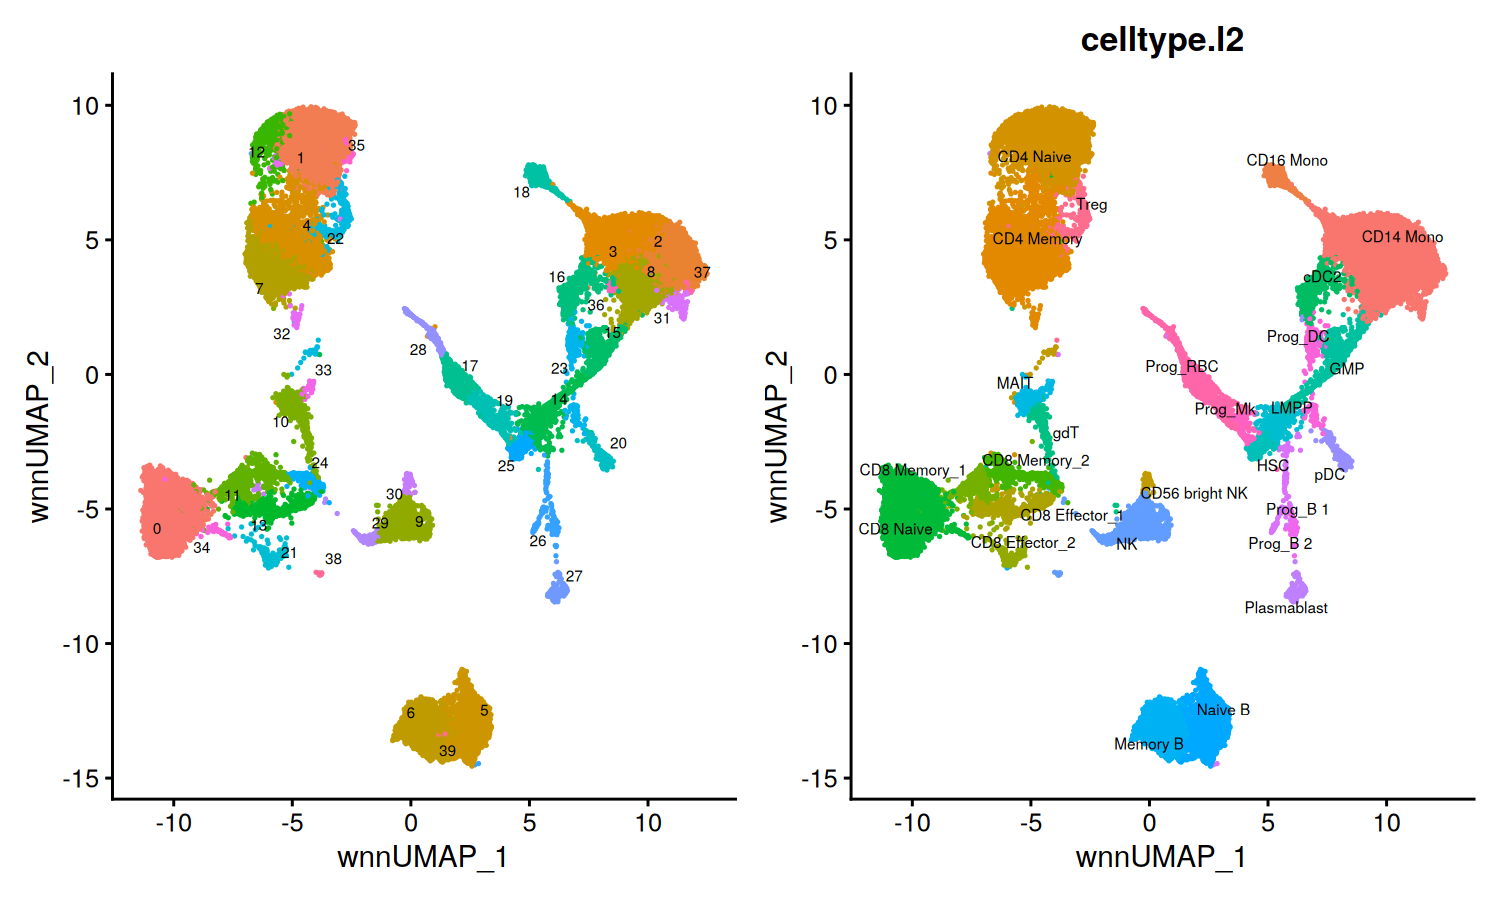

In [22]:
options(repr.plot.width = 10,   # width in inches
        repr.plot.height = 6,   # height in inches
        repr.plot.res = 150)    # resolution

p1 <- DimPlot(bm, reduction = 'wnn.umap', label = TRUE, repel = TRUE, label.size = 2.5) + NoLegend()
p2 <- DimPlot(bm, reduction = 'wnn.umap', group.by = 'celltype.l2', label = TRUE, repel = TRUE, label.size = 2.5) + NoLegend()
p1 + p2

In [23]:
# We can also compute UMAP visualization based on only the RNA and protein data and compare. 
# We find that the RNA analysis is more informative than the ADT analysis in identifying progenitor states 
# (the ADT panel contains markers for differentiated cells), 
# while the converse is true of T cell states (where the ADT analysis outperforms RNA).

In [24]:
bm <- RunUMAP(bm, reduction = 'pca', dims = 1:30, assay = 'RNA', 
              reduction.name = 'rna.umap', reduction.key = 'rnaUMAP_')

bm <- RunUMAP(bm, reduction = 'apca', dims = 1:18, assay = 'ADT', 
              reduction.name = 'adt.umap', reduction.key = 'adtUMAP_')

08:54:38 UMAP embedding parameters a = 0.9922 b = 1.112

08:54:38 Read 30672 rows and found 30 numeric columns

08:54:38 Using Annoy for neighbor search, n_neighbors = 30

08:54:38 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

08:54:40 Writing NN index file to temp file /tmp/RtmpE5mSuj/file976359deb7c7

08:54:40 Searching Annoy index using 1 thread, search_k = 3000

08:54:46 Annoy recall = 100%

08:54:46 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

08:54:47 Initializing from normalized Laplacian + noise (using RSpectra)

08:54:48 Commencing optimization for 200 epochs, with 1427826 positive edges

08:54:48 Using rng type: pcg

08:54:57 Optimization finished

08:54:57 UMAP embedding parameters a = 0.9922 b = 1.112

08:54:57 

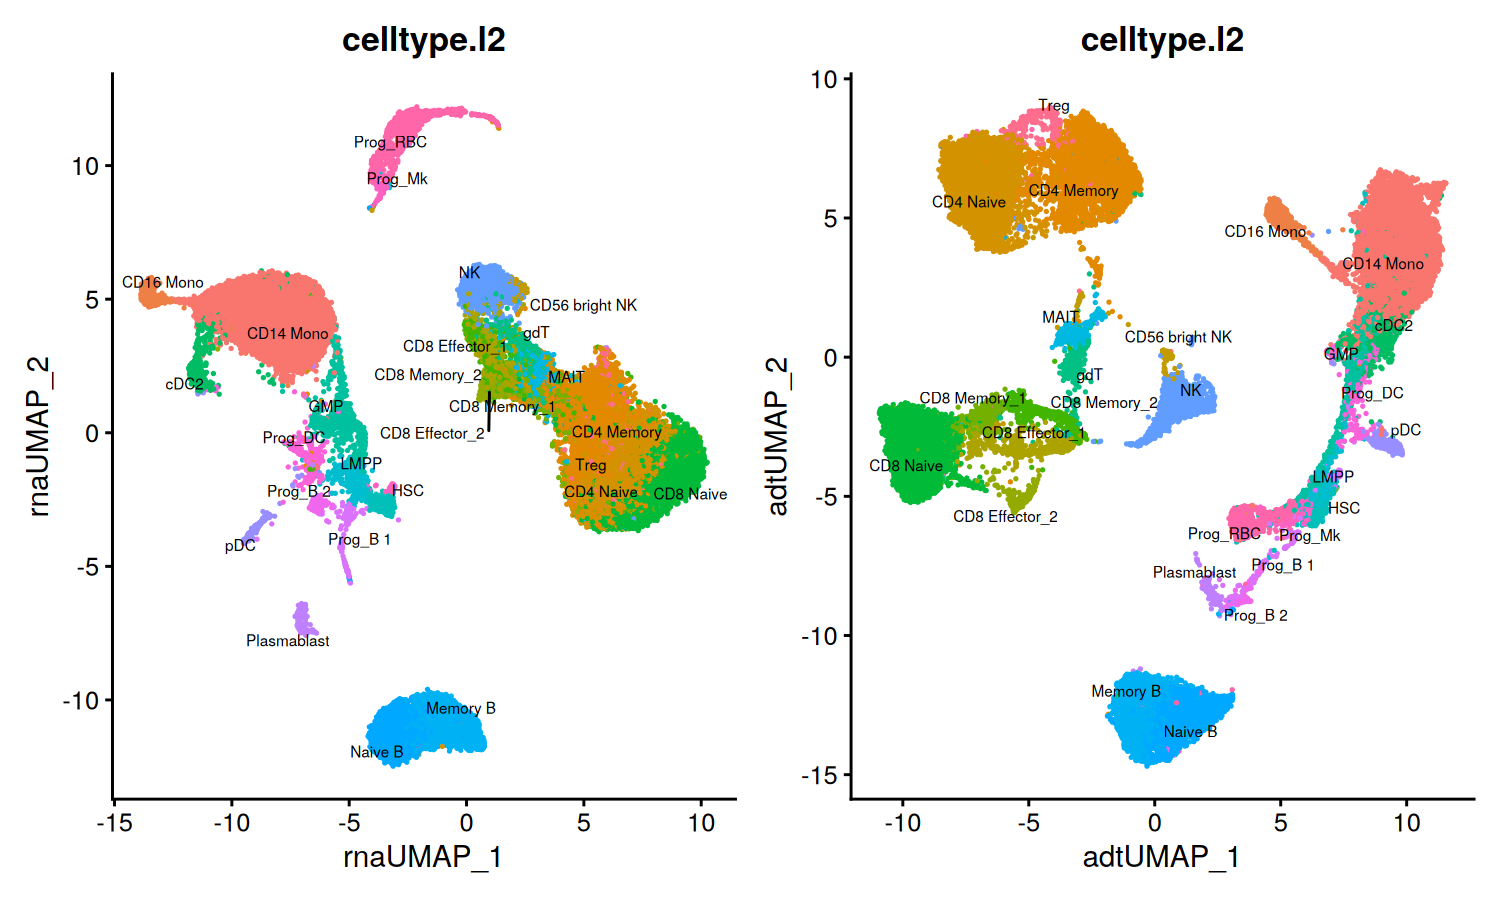

In [25]:
p3 <- DimPlot(bm, reduction = 'rna.umap', group.by = 'celltype.l2', label = TRUE, 
              repel = TRUE, label.size = 2.5) + NoLegend()

p4 <- DimPlot(bm, reduction = 'adt.umap', group.by = 'celltype.l2', label = TRUE, 
              repel = TRUE, label.size = 2.5) + NoLegend()

p3 + p4

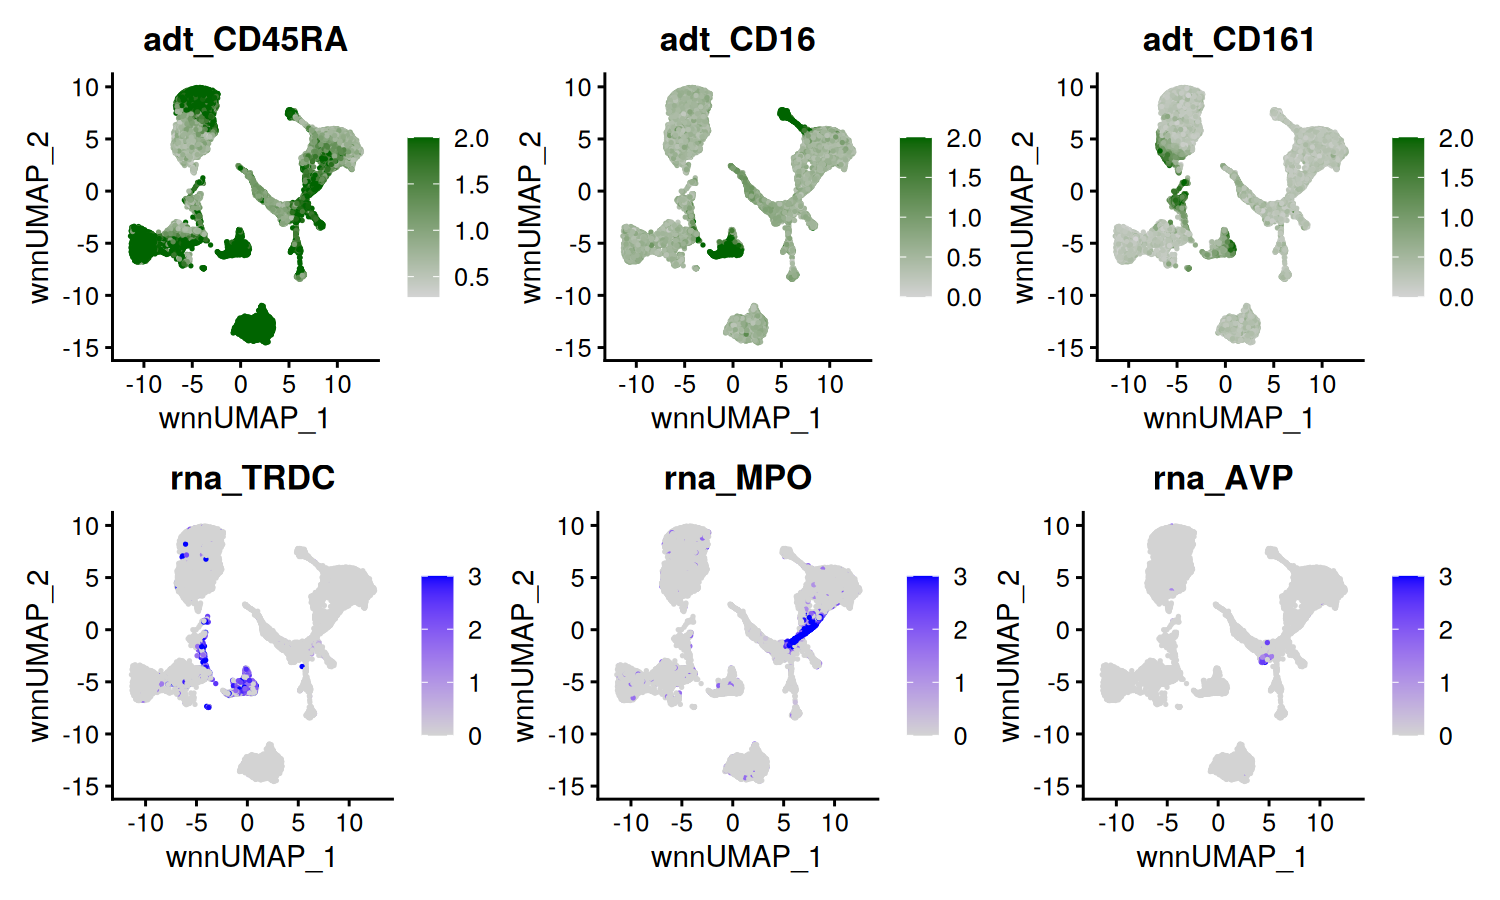

In [26]:
p5 <- FeaturePlot(bm, features = c("adt_CD45RA","adt_CD16","adt_CD161"),
                  reduction = 'wnn.umap', max.cutoff = 2, 
                  cols = c("lightgrey","darkgreen"), ncol = 3)

p6 <- FeaturePlot(bm, features = c("rna_TRDC","rna_MPO","rna_AVP"), 
                  reduction = 'wnn.umap', max.cutoff = 3, ncol = 3)

p5 / p6

In [27]:
# Each of the populations with the highest RNA weights represent progenitor cells, 
# while the populations with the highest protein weights represent T cells.

In [28]:
str(bm)

Formal class 'Seurat' [package "SeuratObject"] with 13 slots
  ..@ assays      :List of 2
  .. ..$ RNA:Formal class 'Assay5' [package "SeuratObject"] with 8 slots
  .. .. .. ..@ layers    :List of 3
  .. .. .. .. ..$ counts    :Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
  .. .. .. .. .. .. ..@ i       : int [1:27198017] 23 31 49 50 58 59 75 77 78 84 ...
  .. .. .. .. .. .. ..@ p       : int [1:30673] 0 2136 2573 3002 3853 4696 5479 6209 7346 7828 ...
  .. .. .. .. .. .. ..@ Dim     : int [1:2] 17009 30672
  .. .. .. .. .. .. ..@ Dimnames:List of 2
  .. .. .. .. .. .. .. ..$ : NULL
  .. .. .. .. .. .. .. ..$ : NULL
  .. .. .. .. .. .. ..@ x       : num [1:27198017] 1 1 1 1 1 2 1 1 1 19 ...
  .. .. .. .. .. .. ..@ factors : list()
  .. .. .. .. ..$ data      :Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
  .. .. .. .. .. .. ..@ i       : int [1:27198017] 23 31 49 50 58 59 75 77 78 84 ...
  .. .. .. .. .. .. ..@ p       : int [1:30673] 0 2136 2573 3002 3853 4696 5

In [29]:
bm@meta.data

,orig.ident,nCount_RNA,nFeature_RNA,nCount_ADT,nFeature_ADT,lane,donor,celltype.l1,celltype.l2,RNA.weight,ADT.weight,wsnn_res.2,seurat_clusters
,<chr>,<dbl>,<int>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<fct>,<fct>
a_AAACCTGAGCTTATCG-1,bmcite,7546,2136,1350,25,HumanHTO4,batch1,Progenitor cells,Prog_RBC,4.872992e-01,0.5127008,19,19
a_AAACCTGAGGTGGGTT-1,bmcite,1029,437,2970,25,HumanHTO1,batch1,T cell,gdT,2.455428e-01,0.7544572,10,10
a_AAACCTGAGTACATGA-1,bmcite,1111,429,2474,23,HumanHTO5,batch1,T cell,CD4 Naive,5.016801e-01,0.4983199,1,1
a_AAACCTGCAAACCTAC-1,bmcite,2741,851,4799,25,HumanHTO3,batch1,T cell,CD4 Memory,4.313079e-01,0.5686921,4,4
a_AAACCTGCAAGGTGTG-1,bmcite,2099,843,5434,25,HumanHTO2,batch1,Mono/DC,CD14 Mono,5.720971e-01,0.4279029,2,2
a_AAACCTGCACGGTAGA-1,bmcite,2291,783,4658,25,HumanHTO6,batch1,B cell,Naive B,4.274557e-01,0.5725443,5,5
a_AAACCTGCACTTGGAT-1,bmcite,2686,730,4365,25,HumanHTO7,batch1,T cell,CD8 Naive,3.258983e-01,0.6741017,0,0
a_AAACCTGCAGATGAGC-1,bmcite,3065,1137,5047,25,HumanHTO10,batch1,Mono/DC,CD14 Mono,3.610977e-01,0.6389023,2,2
a_AAACCTGCAGATGGGT-1,bmcite,1323,482,3484,25,HumanHTO5,batch1,B cell,Naive B,2.027070e-01,0.7972930,5,5


In [30]:
colnames(bm@meta.data)

[1] "orig.ident"      "nCount_RNA"      "nFeature_RNA"    "nCount_ADT"     
 [5] "nFeature_ADT"    "lane"            "donor"           "celltype.l1"    
 [9] "celltype.l2"     "RNA.weight"      "ADT.weight"      "wsnn_res.2"     
[13] "seurat_clusters"

In [31]:
@ graphs      :List of 2
  .. ..$ wknn:Formal class 'Graph' [package "SeuratObject"] with 7 slots
  .. .. .. ..@ assay.used: Named chr "RNA"
  .. .. .. .. ..- attr(*, "names")= chr "pca"
  .. .. .. ..@ i         : int [1:1014222] 0 2247 3305 3637 7567 8633 12399 12915 15010 15447 ...
  .. .. .. ..@ p         : int [1:30673] 0 24 45 81 113 143 180 204 228 275 ...
  .. .. .. ..@ Dim       : int [1:2] 30672 30672
  .. .. .. ..@ Dimnames  :List of 2
  .. .. .. .. ..$ : chr [1:30672] "a_AAACCTGAGCTTATCG-1" "a_AAACCTGAGGTGGGTT-1" "a_AAACCTGAGTACATGA-1" "a_AAACCTGCAAACCTAC-1" ...
  .. .. .. .. ..$ : chr [1:30672] "a_AAACCTGAGCTTATCG-1" "a_AAACCTGAGGTGGGTT-1" "a_AAACCTGAGTACATGA-1" "a_AAACCTGCAAACCTAC-1" ...
  .. .. .. ..@ x         : num [1:1014222] 1 1 1 1 1 1 1 1 1 1 ...
  .. .. .. ..@ factors   : list()
  .. ..$ wsnn:Formal class 'Graph' [package "SeuratObject"] with 7 slots
  .. .. .. ..@ assay.used: Named chr "RNA"
  .. .. .. .. ..- attr(*, "names")= chr "pca"
  .. .. .. ..@ i         : int [1:2195882] 0 161 340 1070 1185 2109 2247 2416 2540 2748 ...
  .. .. .. ..@ p         : int [1:30673] 0 109 129 177 247 331 438 476 529 620 ...
  .. .. .. ..@ Dim       : int [1:2] 30672 30672
  .. .. .. ..@ Dimnames  :List of 2
  .. .. .. .. ..$ : chr [1:30672] "a_AAACCTGAGCTTATCG-1" "a_AAACCTGAGGTGGGTT-1" "a_AAACCTGAGTACATGA-1" "a_AAACCTGCAAACCTAC-1" ...
  .. .. .. .. ..$ : chr [1:30672] "a_AAACCTGAGCTTATCG-1" "a_AAACCTGAGGTGGGTT-1" "a_AAACCTGAGTACATGA-1" "a_AAACCTGCAAACCTAC-1" ...
  .. .. .. ..@ x         : num [1:2195882] 1 0.2903 0.0811 0.25 0.0811 ...
  .. .. .. ..@ factors   : list()
  ..@ neighbors   :List of 1
  .. ..$ weighted.nn:Formal class 'Neighbor' [package "SeuratObject"] with 5 slots
  .. .. .. ..@ nn.idx    : num [1:30672, 1:20] 21408 26747 2354 14276 2344 ...
  .. .. .. ..@ nn.dist   : num [1:30672, 1:20] 0.146 0.204 0.295 0.336 0.296 ...
  .. .. .. ..@ alg.idx   : NULL
  .. .. .. ..@ alg.info  : list()
  .. .. .. ..@ cell.names: chr [1:30672] "a_AAACCTGAGCTTATCG-1" "a_AAACCTGAGGTGGGTT-1" "a_AAACCTGAGTACATGA-1" "a_AAACCTGCAAACCTAC-1" ...
  ..@ reductions  :List of 6

ERROR: Error in parse(text = input): <text>:1:1: unexpected '@'
1: @
    ^


In [ ]:
bm@reductions

In [ ]:
bm@neighbors

In [ ]:
bm@neighbors$weighted.nn

In [ ]:
bm@graphs
str(bm@graphs)

In [ ]:
bm@graphs$wknn

In [ ]:
bm@graphs$wsnn

In [ ]:
# Scatter plot of RNA vs ADT
FeatureScatter(bm, feature1 = "rna_CD3E", feature2 = "adt_CD3")

In [ ]:
options(repr.plot.width = 6,   # width in inches
        repr.plot.height = 6,   # height in inches
        repr.plot.res = 150)    # resolution

# RNA gene expression
FeaturePlot(bm, features = "CD3E", reduction = "wnn.umap")

# ADT protein levels (note the "adt_" prefix)
FeaturePlot(bm, features = "adt_CD3", reduction = "wnn.umap")

options(repr.plot.width = 12,   # width in inches
        repr.plot.height = 6,   # height in inches
        repr.plot.res = 150)    # resolution

# Side by side comparison
FeaturePlot(bm, features = c("CD3E", "adt_CD3"), reduction = "wnn.umap")

In [ ]:
options(repr.plot.width = 6,   # width in inches
        repr.plot.height = 6,   # height in inches
        repr.plot.res = 150)    # resolution

# Visualize the weighted graph
DimPlot(bm, reduction = "wnn.umap", group.by = "seurat_clusters")

options(repr.plot.width = 12,   # width in inches
        repr.plot.height = 4,   # height in inches
        repr.plot.res = 150)    # 

# Check modality weights (RNA vs protein contribution per cell)
VlnPlot(bm, features = "RNA.weight", group.by = "seurat_clusters", pt.size = 0)
VlnPlot(bm, features = "ADT.weight", group.by = "seurat_clusters", pt.size = 0)

In [ ]:
options(repr.plot.width = 26,   # width in inches
        repr.plot.height = 12,   # height in inches
        repr.plot.res = 150)    # resolution

# All ADT markers across clusters
DefaultAssay(bm) <- "ADT"
DotPlot(bm, features = rownames(bm[["ADT"]]), group.by = "seurat_clusters") +
  RotatedAxis()

In [ ]:
# Scatter plot of RNA vs ADT
# FeatureScatter(bm, feature1 = "CD3E", feature2 = "adt_CD3")

In [ ]:
cat("The differences in the protein expression between the clusters")

In [ ]:
DefaultAssay(bm) <- "ADT"

In [ ]:
adt_markers <- FindAllMarkers(
  bm,
  assay = "ADT",
  only.pos = FALSE,    # include both up and down
  min.pct = 0.25,
  logfc.threshold = 0.25
)

# View top markers per cluster
library(dplyr)

adt_markers %>%
  group_by(cluster) %>%
  top_n(n = 5, wt = avg_log2FC)

In [ ]:
# Compare two specific clusters

# Cluster 1 vs Cluster 3

FindMarkers(
  bm,
  assay = "ADT",
  ident.1 = 1,
  ident.2 = 3,
  min.pct = 0.1
)

In [ ]:
options(repr.plot.width = 18,   # width in inches
        repr.plot.height = 6,   # height in inches
        repr.plot.res = 150)    # resolution

VlnPlot(bm, assay = "ADT",
        features = c("CD3", "CD19", "CD14"),
        group.by = "seurat_clusters",
        pt.size = 0)

In [ ]:
options(repr.plot.width = 12,    # width in inches
        repr.plot.height = 12,   # height in inches
        repr.plot.res = 150)     # resolution

FeaturePlot(bm,
            features = c("CD3", "CD19", "CD14", "CD56"),
            reduction = "wnn.umap",
            ncol = 2)

In [ ]:
cat('

Important Note on ADT Normalization : 

# CLR normalization is recommended for ADT before DE
bm <- NormalizeData(bm, assay = "ADT",
                    normalization.method = "CLR",
                    margin = 2)  # margin=2 normalizes across cells

')